# Sentiment Prototype Learning — Steps 3 to 5

### Where we are in the pipeline
```
preprocess.ipynb
       |
       |----------------------------------+
       v                                  v
BERT_embedding.ipynb            ViT_embedding.ipynb
       |                                  |
       v                                  v
text_embeddings.jsonl       image_embeddings.jsonl
       |                                  |
       +-----------------+----------------+
                         v
                   merge.ipynb
                         |
                         v
          interactions_multimodal.jsonl
                         |
                         v
          prototype_learning.ipynb   <-- YOU ARE HERE
                         |
                         v
          interactions_prototype.jsonl
```

### What this notebook does (Steps 3 → 5 from the paper)

**Step 3 — Sentiment Prototype Space**  
We learn a matrix `S ∈ R^(K×768)` of prototype vectors.  
K starts at 5 and **grows dynamically** when the model needs more sentiment  
directions, and **prunes** prototypes that are never attended to.

**Step 4 — Prototype Attention**  
For each interaction we compute softmax attention over prototypes for both  
the image embedding `v_i` and the text embedding `t_ui`, then form  
sentiment-aware representations `z_v` and `z_t` as weighted sums of prototypes.

**Step 5 — Cross-Modal Consistency Loss**  
We penalise disagreement between `z_v` and `z_t` using `||z_v - z_t||²`.  
Combined with the MSE rating loss this forces the image and text to agree  
on the same sentiment reading.

### Output
`interactions_prototype.jsonl` — same records as the multimodal file, augmented  
with `z_v` and `z_t` embeddings, ready for Step 6 (user-guided gating).

---
## Cell 1 — Install dependencies

In [13]:
!pip install torch numpy matplotlib scikit-learn tqdm

---
## Cell 2 — Imports

In [14]:
import json
import math
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import defaultdict
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

print("Imports OK")

Imports OK


---
## Cell 3 — Configuration

All hyperparameters are in one place. Explanations for every value are included  
so you know what to change if training behaves unexpectedly.

In [ ]:
# ── I/O ───────────────────────────────────────────────────────────────────────
INPUT_PATH  = "interactions_multimodal.jsonl"   # output of merge.ipynb
OUTPUT_PATH = "interactions_prototype.jsonl"    # input for Step 6

# ── Embedding ─────────────────────────────────────────────────────────────────
EMB_DIM = 768          # dimension of text_embedding and image_embedding

# ── Prototype hyperparameters ─────────────────────────────────────────────────
K_INIT = 5             # starting number of prototypes
K_MAX  = 100           # semantically motivated ceiling: fine-grained sentiment
                       # rarely needs more than ~20-30 directions

# Grow trigger: if average attention entropy > H_MAX_RATIO * log(K),
# the model adds a new prototype. 0.85 means "if attention is spread
# across 85% of the maximum possible entropy, we need more prototypes".
H_MAX_RATIO = 0.85

# Prune trigger: if a prototype's average attention weight falls below
# PRUNE_THRESHOLD across the whole epoch, it is removed.
# Raised to 0.6 so that prototypes which capture less than 60% of their
# fair share are pruned — this aggressively counterbalances grow pressure.
PRUNE_RATIO = 0.6      # fraction of fair-share attention below which we prune

# Grow cooldown: after adding a prototype, suppress further growth for this
# many epochs. Gives new prototypes time to specialise before entropy is
# re-evaluated, preventing the ratchet effect that causes unbounded K growth.
GROW_COOLDOWN = 5

# Merge threshold: after each grow event, merge any two prototypes whose
# cosine similarity exceeds this value. Prevents near-duplicate proliferation.
MERGE_COSINE_THRESHOLD = 0.95

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS        = 1000
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3

# Lambda controls how strongly the consistency loss is weighted relative
# to the rating MSE loss. Start at 0.1 — if z_v and z_t diverge a lot
# during training you can increase this.
LAMBDA_CONSISTENCY = 0.1

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Input            : {INPUT_PATH}")
print(f"Output           : {OUTPUT_PATH}")
print(f"EMB_DIM          : {EMB_DIM}")
print(f"K_INIT / K_MAX   : {K_INIT} / {K_MAX}")
print(f"Epochs           : {EPOCHS}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Learning rate    : {LEARNING_RATE}")
print(f"Lambda consist.  : {LAMBDA_CONSISTENCY}")
print(f"Device           : {DEVICE}")

Input            : interactions_multimodal.jsonl
Output           : interactions_prototype.jsonl
EMB_DIM          : 768
K_INIT / K_MAX   : 5 / 30
Epochs           : 1000
Batch size       : 32
Learning rate    : 0.001
Lambda consist.  : 0.1
Device           : cuda


---
## Cell 4 — Dataset

Loads `interactions_multimodal.jsonl` and returns tensors per interaction.  
Ratings are normalised from [1, 5] to [0, 1] so the MSE loss has a stable scale.

In [16]:
class MultimodalDataset(Dataset):
    """
    Each item is one (user, asin) interaction from interactions_multimodal.jsonl.
    Returns:
        text_emb  : torch.FloatTensor  shape (EMB_DIM,)  — L2-normalised BERT embedding
        image_emb : torch.FloatTensor  shape (EMB_DIM,)  — L2-normalised CLIP embedding
        rating    : torch.FloatTensor  scalar in [0, 1]  — normalised from [1, 5]
        user_id   : str
        asin      : str
    """

    def __init__(self, path: str):
        self.records = []
        skipped = 0
        with open(path) as f:
            for i, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)

                t = rec.get("text_embedding")
                v = rec.get("image_embedding")
                r = rec.get("rating")

                # Skip if anything is missing or wrong dimension
                if t is None or v is None or r is None:
                    skipped += 1
                    continue
                if len(t) != EMB_DIM or len(v) != EMB_DIM:
                    skipped += 1
                    continue

                self.records.append({
                    "text_emb" : torch.tensor(t, dtype=torch.float32),
                    "image_emb": torch.tensor(v, dtype=torch.float32),
                    # Normalise rating to [0,1]: (r-1)/4
                    "rating"   : torch.tensor((float(r) - 1.0) / 4.0, dtype=torch.float32),
                    "user_id"  : rec["user_id"],
                    "asin"     : rec["asin"],
                    "parent_asin": rec.get("parent_asin"),
                    "timestamp": rec.get("timestamp"),
                    "raw_rating": float(r),
                })

        print(f"Loaded  : {len(self.records):,} interactions")
        if skipped:
            print(f"Skipped : {skipped} records (missing fields or wrong dim)")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]


def collate_fn(batch):
    """Custom collate to keep string fields separate from tensors."""
    return {
        "text_emb"   : torch.stack([b["text_emb"]  for b in batch]),
        "image_emb"  : torch.stack([b["image_emb"] for b in batch]),
        "rating"     : torch.stack([b["rating"]    for b in batch]),
        "user_id"    : [b["user_id"]    for b in batch],
        "asin"       : [b["asin"]       for b in batch],
        "parent_asin": [b["parent_asin"] for b in batch],
        "timestamp"  : [b["timestamp"]  for b in batch],
        "raw_rating" : [b["raw_rating"] for b in batch],
    }


dataset    = MultimodalDataset(INPUT_PATH)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)
print(f"Batches per epoch: {len(dataloader)}")

Loaded  : 166 interactions
Batches per epoch: 6


---
## Cell 5 — Sentiment Prototype Module

This is the core model. It implements Steps 3 and 4 exactly.

### What happens inside `forward()`

1. The prototype matrix `S` (shape `K×768`) is L2-normalised row-wise  
   so every prototype sits on the unit sphere — same space as the input embeddings.

2. For a batch of image embeddings `V` (shape `B×768`) we compute the dot  
   product with every prototype:  
   `scores_v = V @ S^T`  → shape `(B, K)` — this is the cosine similarity  
   because both V and S are L2-normalised.

3. Softmax over K turns scores into attention weights `α_v` — shape `(B, K)`.  

4. Weighted sum: `z_v = α_v @ S` → shape `(B, 768)`.  
   `z_v` is now a sentiment-aware vector in the prototype space.

5. Same procedure for text embeddings → `z_t`.

6. A simple linear head predicts the rating from `(z_v + z_t) / 2`.

In [17]:
class SentimentPrototypeModule(nn.Module):
    """
    Implements Steps 3 and 4 of the multimodal recommendation paper.

    Parameters
    ----------
    k_init : int   — starting number of prototype vectors
    emb_dim: int   — dimension of input embeddings (768)
    """

    def __init__(self, k_init: int, emb_dim: int, temperature: float = 0.07):
        super().__init__()
        self.emb_dim     = emb_dim
        self.temperature = temperature          # <-- add this
        self.prototypes  = nn.Parameter(torch.randn(k_init, emb_dim) * 0.01)
        self.rating_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
    )

    @property
    def K(self) -> int:
        """Current number of active prototypes."""
        return self.prototypes.shape[0]

    def _normalised_prototypes(self) -> torch.Tensor:
        """
        Returns the prototype matrix with each row L2-normalised.
        We normalise here (not in-place on self.prototypes) so that gradients
        still flow through the original unnormalised values.
        Shape: (K, emb_dim)
        """
        return F.normalize(self.prototypes, p=2, dim=1)

    def prototype_attention(self, emb: torch.Tensor):
        S      = self._normalised_prototypes()          # (K, emb_dim)
        scores = emb @ S.T                              # (B, K) cosine similarities
        scores = scores / self.temperature              # <-- divide by τ before softmax
        alphas = F.softmax(scores, dim=1)               # now much more peaked
        z      = alphas @ S
        return z, alphas

    def forward(self, text_emb: torch.Tensor, image_emb: torch.Tensor):
        """
        Full forward pass for a batch.

        Parameters
        ----------
        text_emb  : (B, emb_dim) — BERT text embeddings
        image_emb : (B, emb_dim) — CLIP image embeddings

        Returns
        -------
        y_hat        : (B,)       — predicted ratings in [0, 1]
        z_v          : (B, emb_dim) — sentiment-aware visual embedding
        z_t          : (B, emb_dim) — sentiment-aware text embedding
        alphas_v     : (B, K)     — visual prototype attention weights
        alphas_t     : (B, K)     — text prototype attention weights
        """
        z_v, alphas_v = self.prototype_attention(image_emb)   # Step 4 visual
        z_t, alphas_t = self.prototype_attention(text_emb)    # Step 4 text

        # Simple fusion for rating prediction: average z_v and z_t.
        # (The user-guided gating in Step 6 will replace this with a
        # personalised weighted combination.)
        z_fused = (z_v + z_t) / 2.0                          # (B, emb_dim)

        y_hat = self.rating_head(z_fused).squeeze(1)          # (B,)

        return y_hat, z_v, z_t, alphas_v, alphas_t


# Quick shape smoke-test before training
model = SentimentPrototypeModule(k_init=K_INIT, emb_dim=EMB_DIM).to(DEVICE)
dummy_t = torch.randn(4, EMB_DIM).to(DEVICE)
dummy_v = torch.randn(4, EMB_DIM).to(DEVICE)
# L2-normalise the dummies (same as real data)
dummy_t = F.normalize(dummy_t, p=2, dim=1)
dummy_v = F.normalize(dummy_v, p=2, dim=1)

y_hat, z_v, z_t, av, at = model(dummy_t, dummy_v)
print(f"Model initialised with K = {model.K} prototypes")
print(f"y_hat shape   : {y_hat.shape}   — expected (4,)")
print(f"z_v shape     : {z_v.shape}     — expected (4, {EMB_DIM})")
print(f"z_t shape     : {z_t.shape}     — expected (4, {EMB_DIM})")
print(f"alphas_v shape: {av.shape}       — expected (4, {K_INIT})")
print(f"alphas_t shape: {at.shape}       — expected (4, {K_INIT})")
print(f"y_hat range   : [{y_hat.min().item():.3f}, {y_hat.max().item():.3f}]  — expected in [0,1]")

Model initialised with K = 5 prototypes
y_hat shape   : torch.Size([4])   — expected (4,)
z_v shape     : torch.Size([4, 768])     — expected (4, 768)
z_t shape     : torch.Size([4, 768])     — expected (4, 768)
alphas_v shape: torch.Size([4, 5])       — expected (4, 5)
alphas_t shape: torch.Size([4, 5])       — expected (4, 5)
y_hat range   : [0.484, 0.484]  — expected in [0,1]


---
## Cell 6 — Loss Functions (Steps 4 and 5)

Two loss terms combined:

- **MSE loss** — drives accurate rating prediction (supervision signal that
  pushes prototypes to align with sentiment directions).
- **Consistency loss** — `||z_v - z_t||²` averaged over the batch (Step 5).
  Forces image and text to agree on the same prototype combination.

Total loss = MSE + λ × Consistency

In [18]:
def mse_loss(y_hat: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Standard mean squared error between predicted and true ratings.
    Both y_hat and y are in [0, 1] (normalised).
    """
    return F.mse_loss(y_hat, y)


def consistency_loss(z_v: torch.Tensor, z_t: torch.Tensor) -> torch.Tensor:
    """
    Cross-modal consistency loss from Step 5 of the paper.

    L_consistency = mean over batch of  ||z_v_ui - z_t_ui||²

    Both z_v and z_t are in the prototype space (weighted sums of S rows),
    so this measures how much the image's prototype distribution differs
    from the text's prototype distribution — in the shared sentiment space.

    A value near 0 means both modalities agree on the same prototype blend.
    A high value means the image is 'saying' something different from the text.
    """
    diff  = z_v - z_t                         # (B, emb_dim)
    sq    = (diff ** 2).sum(dim=1)             # (B,)  — squared L2 per sample
    return sq.mean()                           # scalar


def total_loss(
    y_hat: torch.Tensor,
    y: torch.Tensor,
    z_v: torch.Tensor,
    z_t: torch.Tensor,
    lam: float = LAMBDA_CONSISTENCY,
):
    """
    Combined loss returned as a tuple so we can log each component.
    Returns: (total, mse_component, consistency_component)
    """
    l_mse   = mse_loss(y_hat, y)
    l_cons  = consistency_loss(z_v, z_t)
    l_total = l_mse + lam * l_cons
    return l_total, l_mse, l_cons


# Quick sanity check on loss functions
with torch.no_grad():
    dummy_y     = torch.rand(4).to(DEVICE)
    l_t, l_m, l_c = total_loss(y_hat, dummy_y, z_v, z_t)
    print(f"Loss functions OK")
    print(f"  MSE loss         : {l_m.item():.4f}")
    print(f"  Consistency loss : {l_c.item():.4f}")
    print(f"  Total loss       : {l_t.item():.4f}")

Loss functions OK
  MSE loss         : 0.0601
  Consistency loss : 0.0586
  Total loss       : 0.0660


---
## Cell 7 — Dynamic K Manager (Grow + Prune)

This class monitors prototype usage after every epoch and decides whether to  
add or remove prototypes. It directly modifies `model.prototypes` and then  
rebuilds the optimiser so the new parameter is properly tracked.

### Grow logic
Compute mean attention entropy `H = -Σ α_k log(α_k)` over all interactions.  
If `H > H_MAX_RATIO × log(K)` **and** at least `GROW_COOLDOWN` epochs have  
elapsed since the last grow event → attention is still too flat after giving  
existing prototypes time to specialise → add one new prototype. The cooldown  
is critical: without it, grow fires every epoch during early training, causing  
K to ratchet upward unboundedly.

### Merge logic  
After each epoch, compute pairwise cosine similarity between all prototypes.  
If any pair exceeds `MERGE_COSINE_THRESHOLD` (0.95) they are near-duplicates —  
merge them into their normalised mean. This runs *before* the grow check, so  
natural consolidation can relieve entropy pressure without triggering a grow.

### Prune logic  
If a prototype's mean attention weight `< PRUNE_RATIO / K` (far below fair  
share) → it contributes nothing → remove it. `PRUNE_RATIO` is raised to 0.6  
to aggressively counterbalance grow pressure.

Together these three forces — cooldown, merge, prune — ensure K converges  
to a stable value rather than growing without bound.

In [19]:
class DynamicKManager:
    """
    Manages growing and pruning of prototype vectors after each epoch.

    Usage
    -----
    Call .accumulate(alphas_v, alphas_t) inside the training loop every batch.
    Call .step(model, optimiser, epoch) at the end of each epoch.
    Call .reset() at the start of each epoch.
    """

    def __init__(
        self,
        k_max: int,
        h_max_ratio: float,
        prune_ratio: float,
        emb_dim: int,
        lr: float,
        grow_cooldown: int = 5,
        merge_cosine_threshold: float = 0.95,
    ):
        self.k_max                  = k_max
        self.h_max_ratio            = h_max_ratio
        self.prune_ratio            = prune_ratio
        self.emb_dim                = emb_dim
        self.lr                     = lr
        self.grow_cooldown          = grow_cooldown
        self.merge_cosine_threshold = merge_cosine_threshold

        # Running accumulators — reset each epoch
        self._alpha_sum   = None   # sum of alpha vectors over all batches
        self._entropy_sum = 0.0
        self._n_samples   = 0

        # Cooldown tracker: epoch of the last grow event
        self._last_grow_epoch = -grow_cooldown  # allow growth from epoch 0

        # History for logging
        self.k_history      = []   # K value after each epoch
        self.grow_events    = []   # epoch indices where K grew
        self.prune_events   = []   # epoch indices where K shrank
        self.merge_events   = []   # epoch indices where prototypes were merged

    def reset(self):
        """Call at the start of every epoch to clear accumulators."""
        self._alpha_sum   = None
        self._entropy_sum = 0.0
        self._n_samples   = 0

    def accumulate(self, alphas_v: torch.Tensor, alphas_t: torch.Tensor):
        """
        Accumulate attention statistics from one batch.
        alphas_v, alphas_t: (B, K) tensors of softmax attention weights.
        We average the two modalities — both should agree on prototype usage.
        """
        with torch.no_grad():
            # Average the two modality attentions
            alphas = ((alphas_v + alphas_t) / 2.0).cpu()   # (B, K)

            # Accumulate per-prototype mean weights (for prune decision)
            if self._alpha_sum is None:
                self._alpha_sum = alphas.sum(dim=0)         # (K,)
            else:
                self._alpha_sum += alphas.sum(dim=0)

            # Compute entropy per sample: H = -sum(alpha * log(alpha + eps))
            eps     = 1e-10
            entropy = -(alphas * (alphas + eps).log()).sum(dim=1)  # (B,)
            self._entropy_sum += entropy.sum().item()
            self._n_samples   += alphas.shape[0]

    def step(self, model: nn.Module, optimiser: torch.optim.Optimizer, epoch: int):
        """
        Evaluate grow / prune conditions and mutate model.prototypes if needed.
        Returns a new optimiser (always) so the caller does not need to track
        whether a mutation happened.

        FIX: prototypes are always replaced with a NEW nn.Parameter object
        (never mutated in-place), so the old optimiser's stale momentum
        tensors are naturally orphaned.  We then selectively copy momentum
        only for the rating_head parameters, whose shapes never change.
        """
        if self._n_samples == 0:
            self.k_history.append(model.K)
            return optimiser  # nothing accumulated, skip

        K = model.K
        mean_alpha = self._alpha_sum / self._n_samples    # (K,)
        mean_H     = self._entropy_sum / self._n_samples  # scalar
        h_max      = self.h_max_ratio * math.log(K)
        prune_thr  = self.prune_ratio / K

        k_changed = False
        action    = "none"

        # ── Prune dead prototypes first ──────────────────────────────────────
        # Only prune if we have more than 2 prototypes (keep a minimum of 2)
        dead_mask = (mean_alpha < prune_thr)              # (K,) bool
        if dead_mask.any() and K > 2:
            keep_mask  = ~dead_mask
            n_pruned   = dead_mask.sum().item()
            # NEW Parameter object — old optimiser state is now orphaned
            new_protos = nn.Parameter(model.prototypes.data[keep_mask].clone())
            model.prototypes = new_protos
            model = model.to(DEVICE)
            K     = model.K
            k_changed = True
            action = f"pruned {n_pruned} → K={K}"
            self.prune_events.append(epoch)
            # Recompute mean_alpha for grow check after pruning
            mean_alpha = mean_alpha[keep_mask]
            h_max      = self.h_max_ratio * math.log(K)

        # ── Merge near-duplicate prototypes ─────────────────────────────────
        # Run before grow: merging may lower K and relieve entropy pressure
        # naturally, avoiding an unnecessary grow in the same epoch.
        with torch.no_grad():
            S_norm = F.normalize(model.prototypes.data, p=2, dim=1)  # (K, D)
            sim_matrix = S_norm @ S_norm.T                            # (K, K)
            # Only consider upper triangle (avoid self-pairs)
            merged_any = True
            while merged_any:
                merged_any = False
                K_cur = model.prototypes.shape[0]
                if K_cur <= 2:
                    break
                S_n = F.normalize(model.prototypes.data, p=2, dim=1)
                sim = S_n @ S_n.T
                # Zero out diagonal
                sim.fill_diagonal_(0.0)
                max_sim = sim.triu(diagonal=1).max().item()
                if max_sim >= self.merge_cosine_threshold:
                    # Find the most-similar pair
                    flat_idx = sim.triu(diagonal=1).argmax()
                    i_idx = flat_idx // K_cur
                    j_idx = flat_idx % K_cur
                    # Merge: replace i with mean, drop j
                    merged_vec = F.normalize(
                        (model.prototypes.data[i_idx] + model.prototypes.data[j_idx]) / 2.0,
                        p=2, dim=0,
                    ).unsqueeze(0)
                    keep_idx = [x for x in range(K_cur) if x != j_idx.item()]
                    new_data = torch.cat([
                        model.prototypes.data[keep_idx[:i_idx.item()]],
                        merged_vec,
                        model.prototypes.data[keep_idx[i_idx.item()+1:]],
                    ], dim=0)
                    model.prototypes = nn.Parameter(new_data)
                    model = model.to(DEVICE)
                    k_changed = True
                    merged_any = True
                    n_merged = getattr(self, '_n_merged_this_epoch', 0) + 1
                    self._n_merged_this_epoch = n_merged

        if getattr(self, '_n_merged_this_epoch', 0) > 0:
            K = model.K
            n_m = self._n_merged_this_epoch
            action = (action if action != "none" else "") + f" merged {n_m} → K={K}"
            self.merge_events.append(epoch)
            # Recompute h_max and mean_alpha after merge (K changed)
            mean_alpha = self._alpha_sum[:K] / self._n_samples if self._alpha_sum is not None else None
            h_max = self.h_max_ratio * math.log(max(K, 2))
        self._n_merged_this_epoch = 0

        # ── Grow if attention is too flat, K is below ceiling, and cooldown
        #    has elapsed — giving existing prototypes time to specialise ───────
        epochs_since_grow = epoch - self._last_grow_epoch
        if (mean_H > h_max
                and K < self.k_max
                and epochs_since_grow > self.grow_cooldown):
            top2_idx = mean_alpha.topk(min(2, K)).indices
            with torch.no_grad():
                p0      = model.prototypes.data[top2_idx[0]]
                p1      = model.prototypes.data[top2_idx[-1]]
                noise   = torch.randn_like(p0) * 0.01
                new_vec = ((p0 + p1) / 2.0 + noise).unsqueeze(0)   # (1, emb_dim)
                grown   = torch.cat([model.prototypes.data, new_vec], dim=0)
            # NEW Parameter object — old optimiser state is now orphaned
            model.prototypes = nn.Parameter(grown)
            model = model.to(DEVICE)
            K     = model.K
            k_changed = True
            self._last_grow_epoch = epoch
            action = (action if action != "none" else "") + f" grew → K={K}"
            self.grow_events.append(epoch)

        self.k_history.append(K)

        # ── Rebuild optimiser ─────────────────────────────────────────────────
        # Always rebuild so the optimiser tracks the current parameter objects.
        #
        # When K changed: prototypes got a brand-new nn.Parameter, so their
        # Adam state (exp_avg / exp_avg_sq) must start fresh — attempting to
        # copy it would cause a shape mismatch (the old bug).
        # The rating_head parameters are untouched objects, so we CAN safely
        # transfer their momentum, which speeds up re-convergence.
        #
        # When K did NOT change: full state transfer is safe and preserves
        # warm momentum for all parameters.

        new_opt = torch.optim.Adam(model.parameters(), lr=self.lr)

        if not k_changed:
            # Safe to restore full state — no shapes changed
            new_opt.load_state_dict(optimiser.state_dict())
        else:
            # Only restore state for rating_head (shape-stable parameters).
            # Prototype state starts fresh to avoid any shape mismatch.
            old_state   = optimiser.state_dict()
            new_state   = new_opt.state_dict()

            # Build a name→param_id mapping for the OLD optimiser groups.
            # param_groups list order matches model.parameters() order at the
            # time the old optimiser was created:
            #   group 0 params[0] = prototypes  (shape changed — skip)
            #   group 0 params[1..] = rating_head weights/biases (safe)
            old_param_ids = [
                p_id
                for group in old_state["param_groups"]
                for p_id in group["params"]
            ]
            new_param_ids = [
                p_id
                for group in new_state["param_groups"]
                for p_id in group["params"]
            ]

            # The first param_id corresponds to prototypes — skip it.
            # Copy remaining ids (rating_head) if the count still matches.
            old_head_ids = old_param_ids[1:]
            new_head_ids = new_param_ids[1:]

            if len(old_head_ids) == len(new_head_ids):
                for old_id, new_id in zip(old_head_ids, new_head_ids):
                    if old_id in old_state["state"]:
                        new_state["state"][new_id] = old_state["state"][old_id]
                new_opt.load_state_dict(new_state)
            # else: mismatch in head structure (shouldn't happen) — start fresh

        if action != "none":
            print(f"  [DynamicK] Epoch {epoch}: {action.strip()}  "
                  f"(mean_H={mean_H:.3f}, h_max={h_max:.3f})")

        return new_opt


manager = DynamicKManager(
    k_max                  = K_MAX,
    h_max_ratio            = H_MAX_RATIO,
    prune_ratio            = PRUNE_RATIO,
    emb_dim                = EMB_DIM,
    lr                     = LEARNING_RATE,
    grow_cooldown          = GROW_COOLDOWN,
    merge_cosine_threshold = MERGE_COSINE_THRESHOLD,
)
print("DynamicKManager ready")
print(f"  K starts at        : {K_INIT}")
print(f"  K ceiling          : {K_MAX}")
print(f"  Grow trigger       : mean_H > {H_MAX_RATIO} × log(K)")
print(f"  Grow cooldown      : {GROW_COOLDOWN} epochs")
print(f"  Prune trigger      : mean_alpha < {PRUNE_RATIO} / K")
print(f"  Merge threshold    : cosine similarity > {MERGE_COSINE_THRESHOLD}")

DynamicKManager ready
  K starts at        : 5
  K ceiling          : 30
  Grow trigger       : mean_H > 0.85 × log(K)
  Grow cooldown      : 5 epochs
  Prune trigger      : mean_alpha < 0.6 / K
  Merge threshold    : cosine similarity > 0.95


---
## Cell 8 — Training Loop

In [20]:
# Re-initialise model and optimiser cleanly before training
model     = SentimentPrototypeModule(k_init=K_INIT, emb_dim=EMB_DIM).to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
manager.reset()
manager.k_history.clear()
manager.grow_events.clear()
manager.prune_events.clear()

# History for plotting
history = {
    "total_loss"      : [],
    "mse_loss"        : [],
    "consistency_loss": [],
    "k_values"        : [],
}

print(f"Starting training — {EPOCHS} epochs, {len(dataloader)} batches/epoch")
print(f"Initial K = {model.K}")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):

    model.train()
    manager.reset()

    epoch_total = 0.0
    epoch_mse   = 0.0
    epoch_cons  = 0.0
    n_batches   = 0

    for batch in dataloader:
        # L2-normalise embeddings — model uses cosine similarity (dot product
        # of unit vectors), so inputs must sit on the unit sphere.
        text_emb  = F.normalize(batch["text_emb"].to(DEVICE),  p=2, dim=1)
        image_emb = F.normalize(batch["image_emb"].to(DEVICE), p=2, dim=1)
        rating    = batch["rating"].to(DEVICE)      # (B,)

        # Forward pass
        y_hat, z_v, z_t, alphas_v, alphas_t = model(text_emb, image_emb)

        # Compute loss
        l_total, l_mse, l_cons = total_loss(y_hat, rating, z_v, z_t)

        # Backward pass
        optimiser.zero_grad()
        l_total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        # Accumulate for DynamicK and logging
        manager.accumulate(alphas_v.detach(), alphas_t.detach())
        epoch_total += l_total.item()
        epoch_mse   += l_mse.item()
        epoch_cons  += l_cons.item()
        n_batches   += 1

    # ── End of epoch: log and run DynamicK ──────────────────────────────────
    avg_total = epoch_total / n_batches
    avg_mse   = epoch_mse   / n_batches
    avg_cons  = epoch_cons  / n_batches

    history["total_loss"].append(avg_total)
    history["mse_loss"].append(avg_mse)
    history["consistency_loss"].append(avg_cons)
    history["k_values"].append(model.K)

    print(
        f"Epoch {epoch:3d}/{EPOCHS} | "
        f"Loss {avg_total:.4f} "
        f"(MSE {avg_mse:.4f}, Cons {avg_cons:.4f}) | "
        f"K = {model.K}"
    )

    # Grow / prune and rebuild optimiser
    optimiser = manager.step(model, optimiser, epoch)

print("=" * 60)
print(f"Training complete. Final K = {model.K}")
print(f"Grow events at epochs : {manager.grow_events}")
print(f"Prune events at epochs: {manager.prune_events}")

Starting training — 1000 epochs, 6 batches/epoch
Initial K = 5
Epoch   1/1000 | Loss 0.1669 (MSE 0.1609, Cons 0.0607) | K = 5
  [DynamicK] Epoch 1: grew → K=6  (mean_H=1.561, h_max=1.368)
Epoch   2/1000 | Loss 0.1401 (MSE 0.1379, Cons 0.0217) | K = 6
  [DynamicK] Epoch 2: pruned 2 → K=4  (mean_H=1.714, h_max=1.178)
Epoch   3/1000 | Loss 0.0966 (MSE 0.0957, Cons 0.0089) | K = 4
Epoch   4/1000 | Loss 0.0716 (MSE 0.0713, Cons 0.0025) | K = 4
Epoch   5/1000 | Loss 0.0562 (MSE 0.0562, Cons 0.0007) | K = 4
  [DynamicK] Epoch 5: pruned 1 → K=3 merged 1 → K=2  (mean_H=1.315, h_max=0.589)
Epoch   6/1000 | Loss 0.0523 (MSE 0.0522, Cons 0.0003) | K = 2
Epoch   7/1000 | Loss 0.0607 (MSE 0.0607, Cons 0.0005) | K = 2
  [DynamicK] Epoch 7: grew → K=3  (mean_H=0.651, h_max=0.589)
Epoch   8/1000 | Loss 0.0531 (MSE 0.0530, Cons 0.0010) | K = 3
Epoch   9/1000 | Loss 0.0677 (MSE 0.0674, Cons 0.0026) | K = 3
Epoch  10/1000 | Loss 0.0551 (MSE 0.0545, Cons 0.0062) | K = 3
Epoch  11/1000 | Loss 0.0468 (MSE 0.

---
## Cell 9 — Training Diagnostics Plots

Four plots that tell you whether training went well:

1. **Total loss curve** — should decrease and plateau. If it never decreases,  
   lower the learning rate. If it spikes, lower gradient clipping.
2. **MSE vs Consistency loss** — both should decrease. If consistency loss  
   stays high, the image and text embeddings are not aligning — try increasing λ.
3. **K over time** — shows when prototypes were added or removed.
4. **Final prototype attention heatmap** — shows which prototypes each rating  
   level attends to most. Good training = visible banding by rating level.

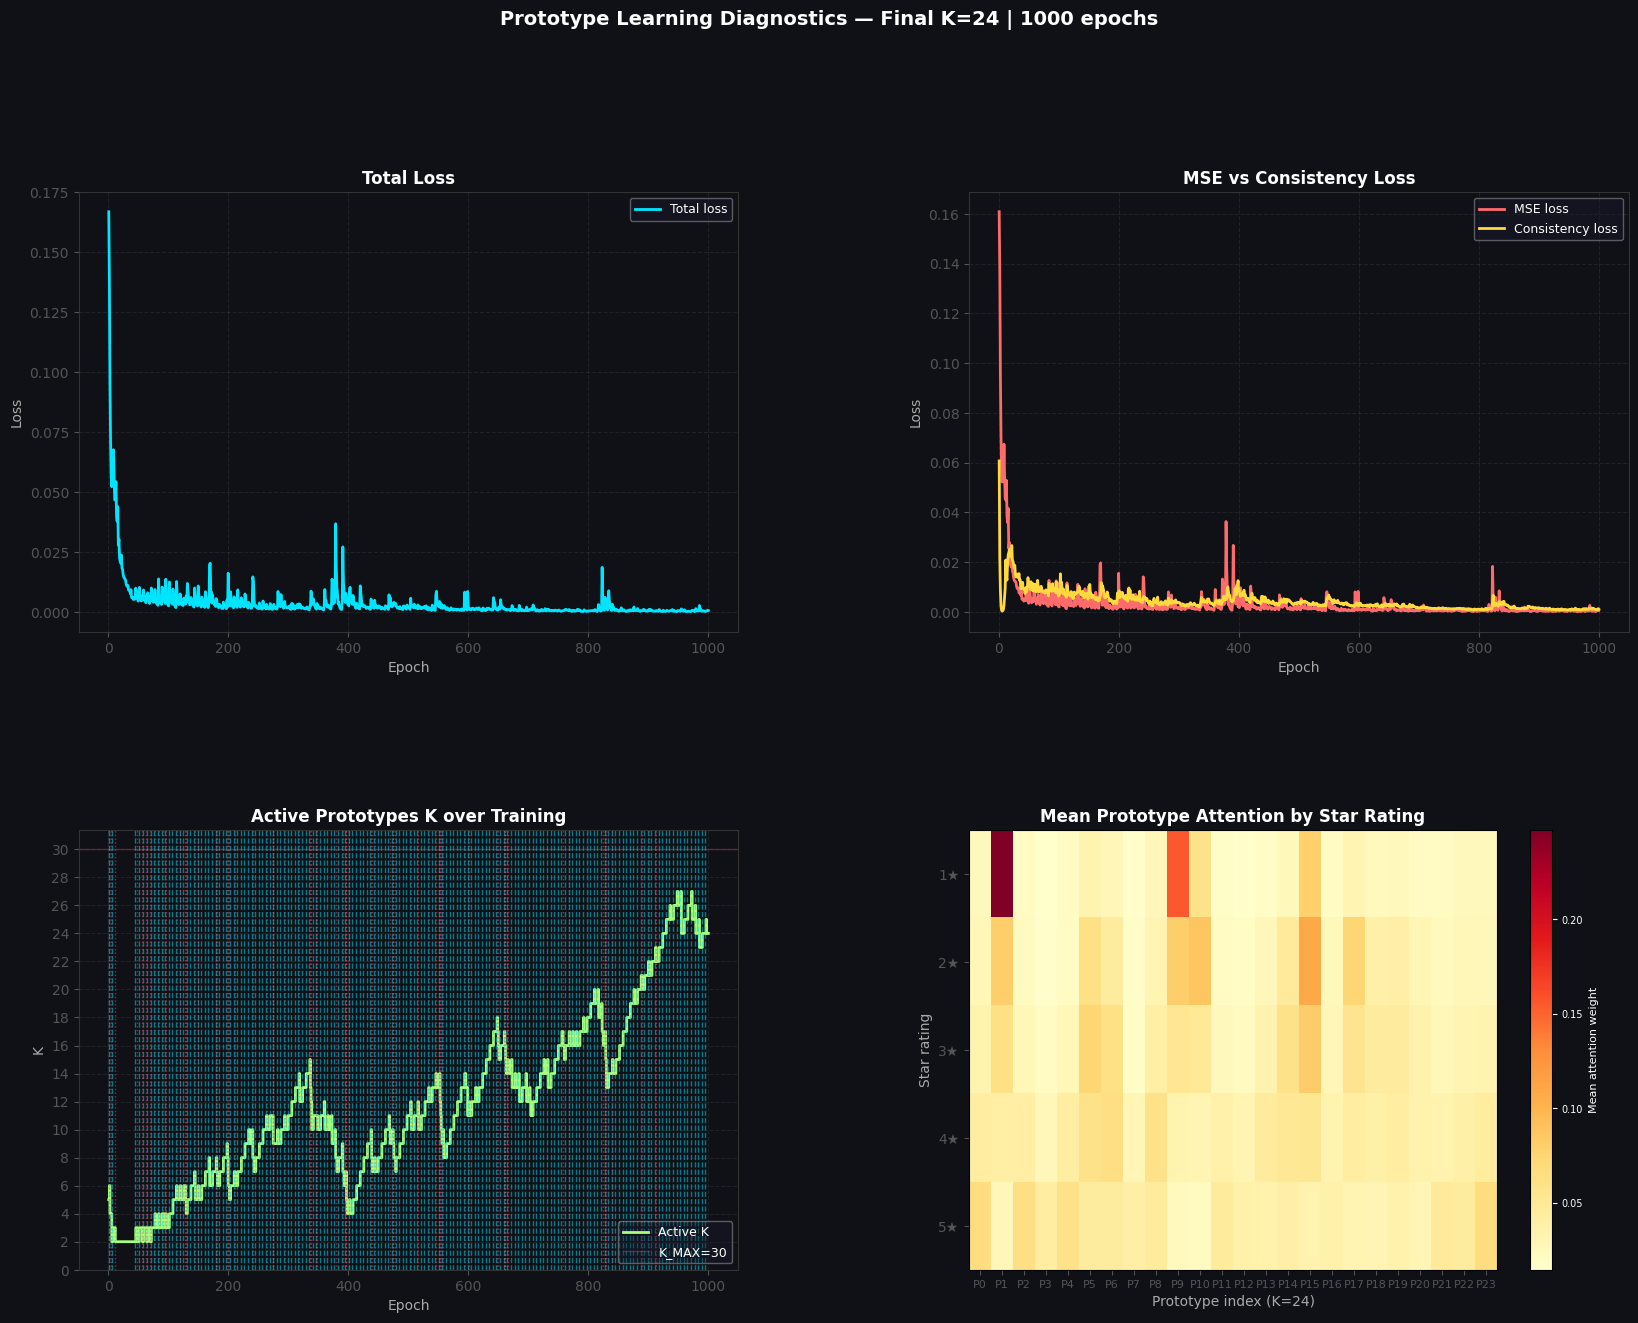

Saved → prototype_training_diagnostics.png


In [21]:
epochs_x = list(range(1, EPOCHS + 1))

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_style = dict(facecolor="#0f1117")

# ── Plot 1: Total loss ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], **ax_style)
ax1.plot(epochs_x, history["total_loss"], color="#00e5ff", linewidth=2, label="Total loss")
ax1.set_title("Total Loss", color="white", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch", color="#aaa")
ax1.set_ylabel("Loss", color="#aaa")
ax1.tick_params(colors="#555")
ax1.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax1.spines.values(): spine.set_edgecolor("#333")
ax1.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

# ── Plot 2: MSE vs Consistency ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], **ax_style)
ax2.plot(epochs_x, history["mse_loss"],         color="#ff6b6b", linewidth=2, label="MSE loss")
ax2.plot(epochs_x, history["consistency_loss"], color="#ffd93d", linewidth=2, label="Consistency loss")
ax2.set_title("MSE vs Consistency Loss", color="white", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch", color="#aaa")
ax2.set_ylabel("Loss", color="#aaa")
ax2.tick_params(colors="#555")
ax2.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax2.spines.values(): spine.set_edgecolor("#333")
ax2.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

# ── Plot 3: K over epochs ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0], **ax_style)
ax3.step(epochs_x, history["k_values"], color="#a8ff78", linewidth=2, where="post", label="Active K")
for ge in manager.grow_events:
    ax3.axvline(ge, color="#00e5ff", alpha=0.5, linewidth=1, linestyle="--")
for pe in manager.prune_events:
    ax3.axvline(pe, color="#ff4d6d", alpha=0.5, linewidth=1, linestyle=":")
ax3.axhline(K_MAX, color="#ff4d6d", alpha=0.3, linewidth=1, linestyle="-", label=f"K_MAX={K_MAX}")
ax3.set_title("Active Prototypes K over Training", color="white", fontsize=12, fontweight="bold")
ax3.set_xlabel("Epoch", color="#aaa")
ax3.set_ylabel("K", color="#aaa")
ax3.set_yticks(range(0, K_MAX + 2, 2))
ax3.tick_params(colors="#555")
ax3.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax3.spines.values(): spine.set_edgecolor("#333")
ax3.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

# ── Plot 4: Prototype attention heatmap by rating bucket ─────────────────────
# Group interactions by rating and compute mean attention per prototype
model.eval()
rating_buckets = {1: [], 2: [], 3: [], 4: [], 5: []}

with torch.no_grad():
    for batch in dataloader:
        text_emb  = batch["text_emb"].to(DEVICE)
        image_emb = batch["image_emb"].to(DEVICE)
        raw_r     = batch["raw_rating"]
        _, _, _, av, at = model(text_emb, image_emb)
        alphas_avg = ((av + at) / 2.0).cpu().numpy()   # (B, K)
        for i, r in enumerate(raw_r):
            bucket = int(round(float(r)))
            if 1 <= bucket <= 5:
                rating_buckets[bucket].append(alphas_avg[i])

heatmap_data = []
for r in [1, 2, 3, 4, 5]:
    if rating_buckets[r]:
        heatmap_data.append(np.mean(rating_buckets[r], axis=0))
    else:
        heatmap_data.append(np.zeros(model.K))

heatmap_arr = np.array(heatmap_data)   # (5, K)

ax4 = fig.add_subplot(gs[1, 1], **ax_style)
K_final = model.K
im = ax4.imshow(
    heatmap_arr,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)
ax4.set_title("Mean Prototype Attention by Star Rating", color="white", fontsize=12, fontweight="bold")
ax4.set_xlabel(f"Prototype index (K={K_final})", color="#aaa")
ax4.set_ylabel("Star rating", color="#aaa")
ax4.set_yticks(range(5))
ax4.set_yticklabels(["1★", "2★", "3★", "4★", "5★"], color="white")
ax4.set_xticks(range(K_final))
ax4.set_xticklabels([f"P{k}" for k in range(K_final)], color="white", fontsize=8)
ax4.tick_params(colors="#555")
cb4 = fig.colorbar(im, ax=ax4)
cb4.set_label("Mean attention weight", color="white", fontsize=8)
cb4.ax.yaxis.set_tick_params(color="white")
plt.setp(cb4.ax.yaxis.get_ticklabels(), color="white", fontsize=7)

fig.suptitle(
    f"Prototype Learning Diagnostics — Final K={model.K} | {EPOCHS} epochs",
    fontsize=14, fontweight="bold", color="white", y=1.01,
)

plt.savefig("prototype_training_diagnostics.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → prototype_training_diagnostics.png")

---
## Cell 10 — Validation: Are the prototype vectors correctly formed?

This cell answers exactly that question for a beginner.  
We run **7 concrete checks**, each with a plain-English explanation of  
what a PASS means and what a FAIL tells you to fix.

### The 7 checks

| # | Check | What a PASS proves |
|---|-------|--------------------|
| 1 | Prototype norms ≈ 1 | Prototypes are L2-normalised (unit sphere) |
| 2 | Attention weights sum to 1 | Softmax is working correctly |
| 3 | z_v and z_t norms reasonable | Weighted sums are in valid range |
| 4 | Consistency loss decreased | Image and text are aligning in prototype space |
| 5 | MSE decreased | Rating supervision is working |
| 6 | High-rating interactions prefer different prototypes than low-rating | Prototypes have semantic meaning |
| 7 | z_v and z_t are more similar after training than before | Cross-modal alignment improved |

In [22]:
print("=" * 60)
print("VALIDATION: Are the prototype vectors correctly formed?")
print("=" * 60)

model.eval()
all_pass = True

def check(label, condition, pass_msg, fail_msg):
    global all_pass
    status = "✅ PASS" if condition else "❌ FAIL"
    if not condition:
        all_pass = False
    print(f"\n{status}  {label}")
    if condition:
        print(f"       {pass_msg}")
    else:
        print(f"       {fail_msg}")


# ── Check 1: Prototype norms ──────────────────────────────────────────────────
with torch.no_grad():
    S_norm = model._normalised_prototypes()
    proto_norms = S_norm.norm(dim=1).cpu().numpy()

norms_ok = np.allclose(proto_norms, 1.0, atol=1e-4)
check(
    f"Prototype L2 norms (K={model.K})",
    norms_ok,
    f"All {model.K} prototype norms = 1.0 ± 1e-4. "
    f"Min={proto_norms.min():.5f}, Max={proto_norms.max():.5f}. "
    "Prototypes sit on the unit sphere — cosine similarity with "
    "embeddings is well-defined.",
    f"Prototype norms deviate from 1: {proto_norms}. "
    "This means L2 normalisation in _normalised_prototypes() broke — "
    "check the F.normalize call.",
)


# ── Check 2: Attention weights sum to 1 ──────────────────────────────────────
sample_batch = next(iter(dataloader))
with torch.no_grad():
    te = sample_batch["text_emb"].to(DEVICE)
    ie = sample_batch["image_emb"].to(DEVICE)
    _, z_v_s, z_t_s, av_s, at_s = model(te, ie)

alpha_sums_v = av_s.sum(dim=1).cpu().numpy()
alpha_sums_t = at_s.sum(dim=1).cpu().numpy()
sums_ok = (
    np.allclose(alpha_sums_v, 1.0, atol=1e-4) and
    np.allclose(alpha_sums_t, 1.0, atol=1e-4)
)
check(
    "Attention weights sum to 1",
    sums_ok,
    f"Visual attentions sum: mean={alpha_sums_v.mean():.5f}, "
    f"Text attentions sum: mean={alpha_sums_t.mean():.5f}. "
    "Softmax is operating correctly — every prototype gets a share of "
    "attention that adds up to exactly 1 per sample.",
    "Attention weights do NOT sum to 1. Softmax might be applied on the "
    "wrong dimension — check `F.softmax(scores, dim=1)` in prototype_attention().",
)


# ── Check 3: z_v and z_t norms ────────────────────────────────────────────────
with torch.no_grad():
    zv_norms = z_v_s.norm(dim=1).cpu().numpy()
    zt_norms = z_t_s.norm(dim=1).cpu().numpy()

# z_v = weighted sum of unit vectors, so norm must be ≤ 1 and > 0
norms_reasonable = (
    (zv_norms > 0).all() and (zv_norms <= 1.0 + 1e-4).all() and
    (zt_norms > 0).all() and (zt_norms <= 1.0 + 1e-4).all()
)
check(
    "z_v and z_t norms in (0, 1]",
    norms_reasonable,
    f"z_v norms: mean={zv_norms.mean():.4f}, min={zv_norms.min():.4f}. "
    f"z_t norms: mean={zt_norms.mean():.4f}, min={zt_norms.min():.4f}. "
    "Since z is a convex combination of unit vectors, norm ≤ 1 is guaranteed. "
    "This confirms the weighted-sum formula is correct.",
    f"z norms out of expected range. "
    f"z_v norms: {zv_norms[:5]}. z_t norms: {zt_norms[:5]}. "
    "Check that prototypes are normalised before the weighted sum.",
)


# ── Check 4: Consistency loss decreased ──────────────────────────────────────
cons_start = history["consistency_loss"][0]
cons_end   = history["consistency_loss"][-1]
cons_decreased = cons_end < cons_start
check(
    "Consistency loss decreased over training",
    cons_decreased,
    f"Start={cons_start:.4f} → End={cons_end:.4f} "
    f"(↓ {100*(cons_start-cons_end)/max(cons_start,1e-8):.1f}%). "
    "Image and text prototype attention distributions are converging. "
    "Both modalities are learning to read sentiment the same way.",
    f"Start={cons_start:.4f} → End={cons_end:.4f}. "
    "Consistency loss did not decrease. Try increasing LAMBDA_CONSISTENCY "
    "(currently {LAMBDA_CONSISTENCY}) to give alignment a stronger signal.",
)


# ── Check 5: MSE decreased ────────────────────────────────────────────────────
mse_start = history["mse_loss"][0]
mse_end   = history["mse_loss"][-1]
mse_decreased = mse_end < mse_start
check(
    "MSE loss decreased over training",
    mse_decreased,
    f"Start={mse_start:.4f} → End={mse_end:.4f} "
    f"(↓ {100*(mse_start-mse_end)/max(mse_start,1e-8):.1f}%). "
    "Rating supervision is working — prototypes are shifting into "
    "sentiment-aligned directions.",
    f"MSE did not decrease (Start={mse_start:.4f}, End={mse_end:.4f}). "
    "Try a higher learning rate or more epochs.",
)


# ── Check 6: Semantic differentiation by rating ───────────────────────────────
# Compute mean attention per rating bucket over the full dataset
K_final = model.K
rating_buckets_check = {1: [], 2: [], 3: [], 4: [], 5: []}

with torch.no_grad():
    for batch in dataloader:
        te  = batch["text_emb"].to(DEVICE)
        ie  = batch["image_emb"].to(DEVICE)
        rr  = batch["raw_rating"]
        _, _, _, av_b, at_b = model(te, ie)
        avg_alpha = ((av_b + at_b) / 2.0).cpu().numpy()
        for i, r in enumerate(rr):
            b = int(round(float(r)))
            if 1 <= b <= 5:
                rating_buckets_check[b].append(avg_alpha[i])

bucket_means = {}
for r in [1, 2, 3, 4, 5]:
    if rating_buckets_check[r]:
        bucket_means[r] = np.mean(rating_buckets_check[r], axis=0)  # (K,)

# The dominant prototype (argmax) should differ between 1-star and 5-star
semantic_ok = False
dominant_proto_info = "Not enough rating diversity in the dataset."
if 1 in bucket_means and 5 in bucket_means:
    dom_low  = int(np.argmax(bucket_means[1]))
    dom_high = int(np.argmax(bucket_means[5]))
    semantic_ok = (dom_low != dom_high)
    dominant_proto_info = (
        f"1★ dominant prototype: P{dom_low} "
        f"(weight={bucket_means[1][dom_low]:.3f})  |  "
        f"5★ dominant prototype: P{dom_high} "
        f"(weight={bucket_means[5][dom_high]:.3f})"
    )

check(
    "Different ratings attend to different prototypes",
    semantic_ok,
    dominant_proto_info + " — Prototypes have acquired semantic meaning: "
    "1-star and 5-star reviews consistently activate different prototypes. "
    "This is the core signal that the prototype space is working.",
    dominant_proto_info + " — 1-star and 5-star reviews activate the same "
    "dominant prototype. The model has not yet separated sentiment polarities. "
    "Try more epochs or a smaller learning rate.",
)


# ── Check 7: Cross-modal cosine similarity improved ────────────────────────────
# Compare cosine similarity between z_v and z_t from a random untrained
# model vs the trained model. Should be higher after training.
untrained_model = SentimentPrototypeModule(k_init=model.K, emb_dim=EMB_DIM).to(DEVICE)
untrained_model.eval()

def mean_cosine_sim_zv_zt(m):
    sims = []
    with torch.no_grad():
        for batch in dataloader:
            te = batch["text_emb"].to(DEVICE)
            ie = batch["image_emb"].to(DEVICE)
            _, zv, zt, _, _ = m(te, ie)
            # Cosine similarity per sample
            cos = F.cosine_similarity(zv, zt, dim=1).cpu().numpy()
            sims.extend(cos.tolist())
    return np.mean(sims)

cos_before = mean_cosine_sim_zv_zt(untrained_model)
cos_after  = mean_cosine_sim_zv_zt(model)
alignment_improved = cos_after > cos_before

check(
    "Cross-modal cosine similarity z_v·z_t increased after training",
    alignment_improved,
    f"Before training (random model): {cos_before:.4f}  →  "
    f"After training: {cos_after:.4f}. "
    "Image and text prototype representations have become more aligned. "
    "The consistency loss is doing its job.",
    f"Before training: {cos_before:.4f}, After training: {cos_after:.4f}. "
    "Similarity did not increase. The consistency loss may need a larger "
    "lambda, or training may need more epochs.",
)


print("\n" + "=" * 60)
if all_pass:
    print("🎉  ALL 7 CHECKS PASSED — prototype vectors are correctly formed.")
    print("    Proceed to saving outputs and then to Step 6 (user-guided gating).")
else:
    print("⚠️   SOME CHECKS FAILED — review the FAIL messages above.")
    print("    The most common fixes: more epochs, tune LAMBDA_CONSISTENCY, "
          "check embedding norms from the merge file.")
print("=" * 60)

VALIDATION: Are the prototype vectors correctly formed?

✅ PASS  Prototype L2 norms (K=24)
       All 24 prototype norms = 1.0 ± 1e-4. Min=1.00000, Max=1.00000. Prototypes sit on the unit sphere — cosine similarity with embeddings is well-defined.

✅ PASS  Attention weights sum to 1
       Visual attentions sum: mean=1.00000, Text attentions sum: mean=1.00000. Softmax is operating correctly — every prototype gets a share of attention that adds up to exactly 1 per sample.

✅ PASS  z_v and z_t norms in (0, 1]
       z_v norms: mean=0.7642, min=0.7205. z_t norms: mean=0.7639, min=0.7405. Since z is a convex combination of unit vectors, norm ≤ 1 is guaranteed. This confirms the weighted-sum formula is correct.

✅ PASS  Consistency loss decreased over training
       Start=0.0607 → End=0.0011 (↓ 98.1%). Image and text prototype attention distributions are converging. Both modalities are learning to read sentiment the same way.

✅ PASS  MSE loss decreased over training
       Start=0.1609 → 

---
## Cell 11 — Visualise: Prototype Space via PCA

Projects the learned prototype vectors and a sample of `z_v` / `z_t` embeddings  
into 2D using PCA. This is the clearest visual confirmation that the prototype  
space has structure:

- Prototype vectors should spread out (not cluster at the same point)
- 1-star `z_v` / `z_t` dots should sit near different prototypes than 5-star ones
- `z_v` and `z_t` dots for the same interaction should be close together

/tmp/ipykernel_5063/2389406509.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


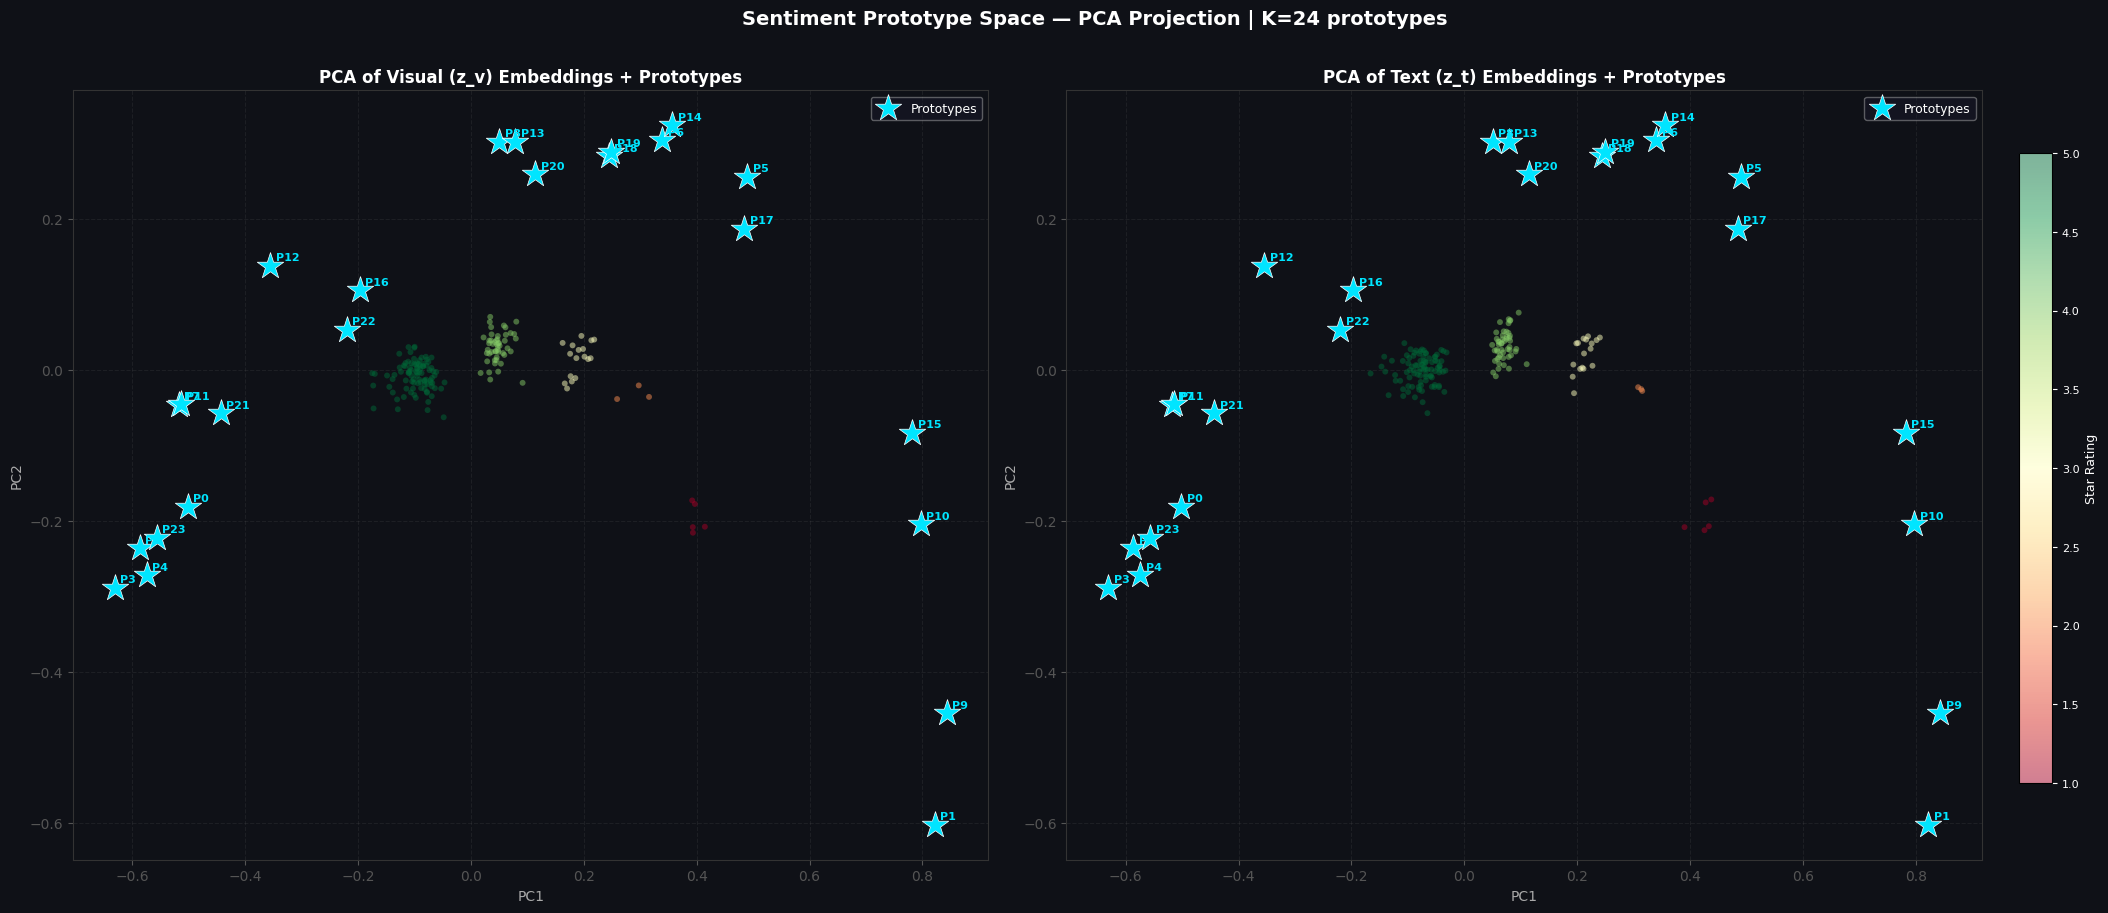

Saved → prototype_space_pca.png

What to look for:
  ✓ Prototype stars (P0, P1, ...) are spread out — not all in one cluster
  ✓ Red dots (1★) and green dots (5★) sit in different regions
  ✓ z_v and z_t PCA plots look similar — both modalities in same space


In [23]:
# Collect z_v, z_t, prototype vectors, and ratings for PCA
all_zv, all_zt, all_ratings = [], [], []

model.eval()
with torch.no_grad():
    for batch in dataloader:
        te = batch["text_emb"].to(DEVICE)
        ie = batch["image_emb"].to(DEVICE)
        rr = batch["raw_rating"]
        _, zv, zt, _, _ = model(te, ie)
        all_zv.extend(zv.cpu().numpy())
        all_zt.extend(zt.cpu().numpy())
        all_ratings.extend([float(r) for r in rr])

all_zv      = np.array(all_zv)       # (N, 768)
all_zt      = np.array(all_zt)       # (N, 768)
all_ratings = np.array(all_ratings)  # (N,)

protos_np = model._normalised_prototypes().detach().cpu().numpy()  # (K, 768)

# PCA fit on z_v + prototypes combined so they share the same 2D space
combined  = np.vstack([all_zv, protos_np])
pca       = PCA(n_components=2)
combined_2d = pca.fit_transform(combined)

zv_2d    = combined_2d[:len(all_zv)]
proto_2d = combined_2d[len(all_zv):]

# Project z_t into the same PCA space
zt_2d = pca.transform(all_zt)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.patch.set_facecolor("#0f1117")
cmap = plt.cm.RdYlGn

for ax, emb_2d, modality in [(axes[0], zv_2d, "Visual (z_v)"),
                               (axes[1], zt_2d, "Text (z_t)")]:
    ax.set_facecolor("#0f1117")
    for spine in ax.spines.values(): spine.set_edgecolor("#333")

    # Plot interaction embeddings coloured by rating
    sc = ax.scatter(
        emb_2d[:, 0], emb_2d[:, 1],
        c=all_ratings, cmap=cmap, vmin=1, vmax=5,
        s=18, alpha=0.5, edgecolors="none", zorder=2,
    )

    # Plot prototype vectors as large stars
    ax.scatter(
        proto_2d[:, 0], proto_2d[:, 1],
        marker="*", s=400, color="#00e5ff",
        edgecolors="white", linewidths=0.5, zorder=5, label="Prototypes",
    )
    for k in range(len(proto_2d)):
        ax.annotate(
            f"P{k}",
            xy=(proto_2d[k, 0], proto_2d[k, 1]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=8, color="#00e5ff", fontweight="bold", zorder=6,
        )

    ax.set_title(f"PCA of {modality} Embeddings + Prototypes",
                 color="white", fontsize=12, fontweight="bold")
    ax.set_xlabel("PC1", color="#aaa")
    ax.set_ylabel("PC2", color="#aaa")
    ax.tick_params(colors="#555")
    ax.grid(True, linestyle="--", alpha=0.12, color="#888")
    ax.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cb = fig.colorbar(sc, cax=cbar_ax)
cb.set_label("Star Rating", color="white", fontsize=9)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    f"Sentiment Prototype Space — PCA Projection | K={model.K} prototypes",
    fontsize=14, fontweight="bold", color="white", y=1.01,
)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig("prototype_space_pca.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → prototype_space_pca.png")
print(f"\nWhat to look for:")
print(f"  ✓ Prototype stars (P0, P1, ...) are spread out — not all in one cluster")
print(f"  ✓ Red dots (1★) and green dots (5★) sit in different regions")
print(f"  ✓ z_v and z_t PCA plots look similar — both modalities in same space")

---
## Cell 12 — Save outputs

Writes `interactions_prototype.jsonl` — one record per interaction, augmented  
with `z_v` and `z_t`. This is the input for Step 6 (user-guided gating).

### Output schema
```json
{
  "user_id"     : str,
  "asin"        : str,
  "parent_asin" : str,
  "rating"      : float,
  "timestamp"   : int,
  "z_v"         : list[float],   // len = 768, sentiment-aware visual embedding
  "z_t"         : list[float],   // len = 768, sentiment-aware text embedding
  "final_k"     : int            // K value used to produce this record
}
```

In [24]:
print(f"Generating final embeddings and saving to {OUTPUT_PATH}...")

model.eval()
K_final = model.K
written = 0

with open(OUTPUT_PATH, "w") as out_f:
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Saving"):
            te  = batch["text_emb"].to(DEVICE)
            ie  = batch["image_emb"].to(DEVICE)
            _, zv, zt, _, _ = model(te, ie)

            zv_np = zv.cpu().numpy()
            zt_np = zt.cpu().numpy()

            B = zv_np.shape[0]
            for i in range(B):
                record = {
                    "user_id"    : batch["user_id"][i],
                    "asin"       : batch["asin"][i],
                    "parent_asin": batch["parent_asin"][i],
                    "rating"     : batch["raw_rating"][i],
                    "timestamp"  : batch["timestamp"][i],
                    "z_v"        : zv_np[i].tolist(),
                    "z_t"        : zt_np[i].tolist(),
                    "final_k"    : K_final,
                }
                out_f.write(json.dumps(record) + "\n")
                written += 1

print(f"\nSaved {written:,} records → {OUTPUT_PATH}")
print(f"Each record contains:")
print(f"  z_v : dim {EMB_DIM} sentiment-aware visual embedding")
print(f"  z_t : dim {EMB_DIM} sentiment-aware text embedding")
print(f"  final_k : {K_final}  (number of prototypes used)")
print()
print("Next step → Step 6: User-Guided Gating (gating.ipynb)")
print("  Inputs  : interactions_prototype.jsonl")
print("  Computes: g = σ(Wg [z_v; z_t; u])")
print("            Z_ui = g ⊙ z_v + (1-g) ⊙ z_t")
print("            ŷ_ui = Wr^T Z_ui + br")

Generating final embeddings and saving to interactions_prototype.jsonl...


Saving: 100%|██████████| 6/6 [00:00<00:00, 17.81it/s]


Saved 166 records → interactions_prototype.jsonl
Each record contains:
  z_v : dim 768 sentiment-aware visual embedding
  z_t : dim 768 sentiment-aware text embedding
  final_k : 24  (number of prototypes used)

Next step → Step 6: User-Guided Gating (gating.ipynb)
  Inputs  : interactions_prototype.jsonl
  Computes: g = σ(Wg [z_v; z_t; u])
            Z_ui = g ⊙ z_v + (1-g) ⊙ z_t
            ŷ_ui = Wr^T Z_ui + br
